In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_path = 'data/train.csv'
test_path = 'data/test.csv'
submission_path = 'data/sample_submission.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(submission_path)

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Sample submission shape:', sample_submission.shape)

display(train.head())
display(test.head())


Train shape: (140700, 20)
Test shape: (93800, 19)
Sample submission shape: (93800, 2)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,140700,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,140701,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,140702,Yash,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No
3,140703,Nalini,Female,23.0,Rajkot,Student,NaN,5.0,NaN,6.84,1.0,NaN,More than 8 hours,Moderate,BSc,Yes,10.0,4.0,No
4,140704,Shaurya,Male,47.0,Kalyan,Working Professional,Teacher,NaN,5.0,NaN,NaN,5.0,7-8 hours,Moderate,BCA,Yes,3.0,4.0,No


In [4]:
target_col = 'Depression'
id_col = 'id'

print(train.columns)

Index(['id', 'Name', 'Gender', 'Age', 'City',
       'Working Professional or Student', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


In [6]:
def missing_table(df):
    out = pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': df.isna().mean() * 100,
        'dtype': df.dtypes.astype(str),
        'n_unique': df.nunique(dropna=True)
    })
    return out.sort_values('missing_pct', ascending=False)

train_missing = missing_table(train)
test_missing = missing_table(test)

display(train_missing)


,missing_count,missing_pct,dtype,n_unique
Study Satisfaction,112803,80.172708,float64,5
Academic Pressure,112803,80.172708,float64,5
CGPA,112802,80.171997,float64,331
Profession,36630,26.034115,object,64
Work Pressure,27918,19.842217,float64,5
Job Satisfaction,27910,19.836532,float64,5
Dietary Habits,4,0.002843,object,23
Financial Stress,4,0.002843,float64,5
Degree,2,0.001421,object,115
Family History of Mental Illness,0,0.000000,object,2


In [8]:
target_counts = train[target_col].value_counts().sort_index()
target_rate = train[target_col].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({'count': target_counts, 'pct': target_rate}))

,count,pct
Depression,,
0,115133,81.828714
1,25567,18.171286


,count,mean,std,min,25%,50%,75%,max
Age,140700.0,40.388621,12.384099,18.00,29.00,42.00,51.00,60.0
Academic Pressure,27897.0,3.142273,1.380457,1.00,2.00,3.00,4.00,5.0
Work Pressure,112782.0,2.998998,1.405771,1.00,2.00,3.00,4.00,5.0
CGPA,27898.0,7.658636,1.464466,5.03,6.29,7.77,8.92,10.0
Study Satisfaction,27897.0,2.944940,1.360197,1.00,2.00,3.00,4.00,5.0
Job Satisfaction,112790.0,2.974404,1.416078,1.00,2.00,3.00,4.00,5.0
Work/Study Hours,140700.0,6.252679,3.853615,0.00,3.00,6.00,10.00,12.0
Financial Stress,140696.0,2.988983,1.413633,1.00,2.00,3.00,4.00,5.0


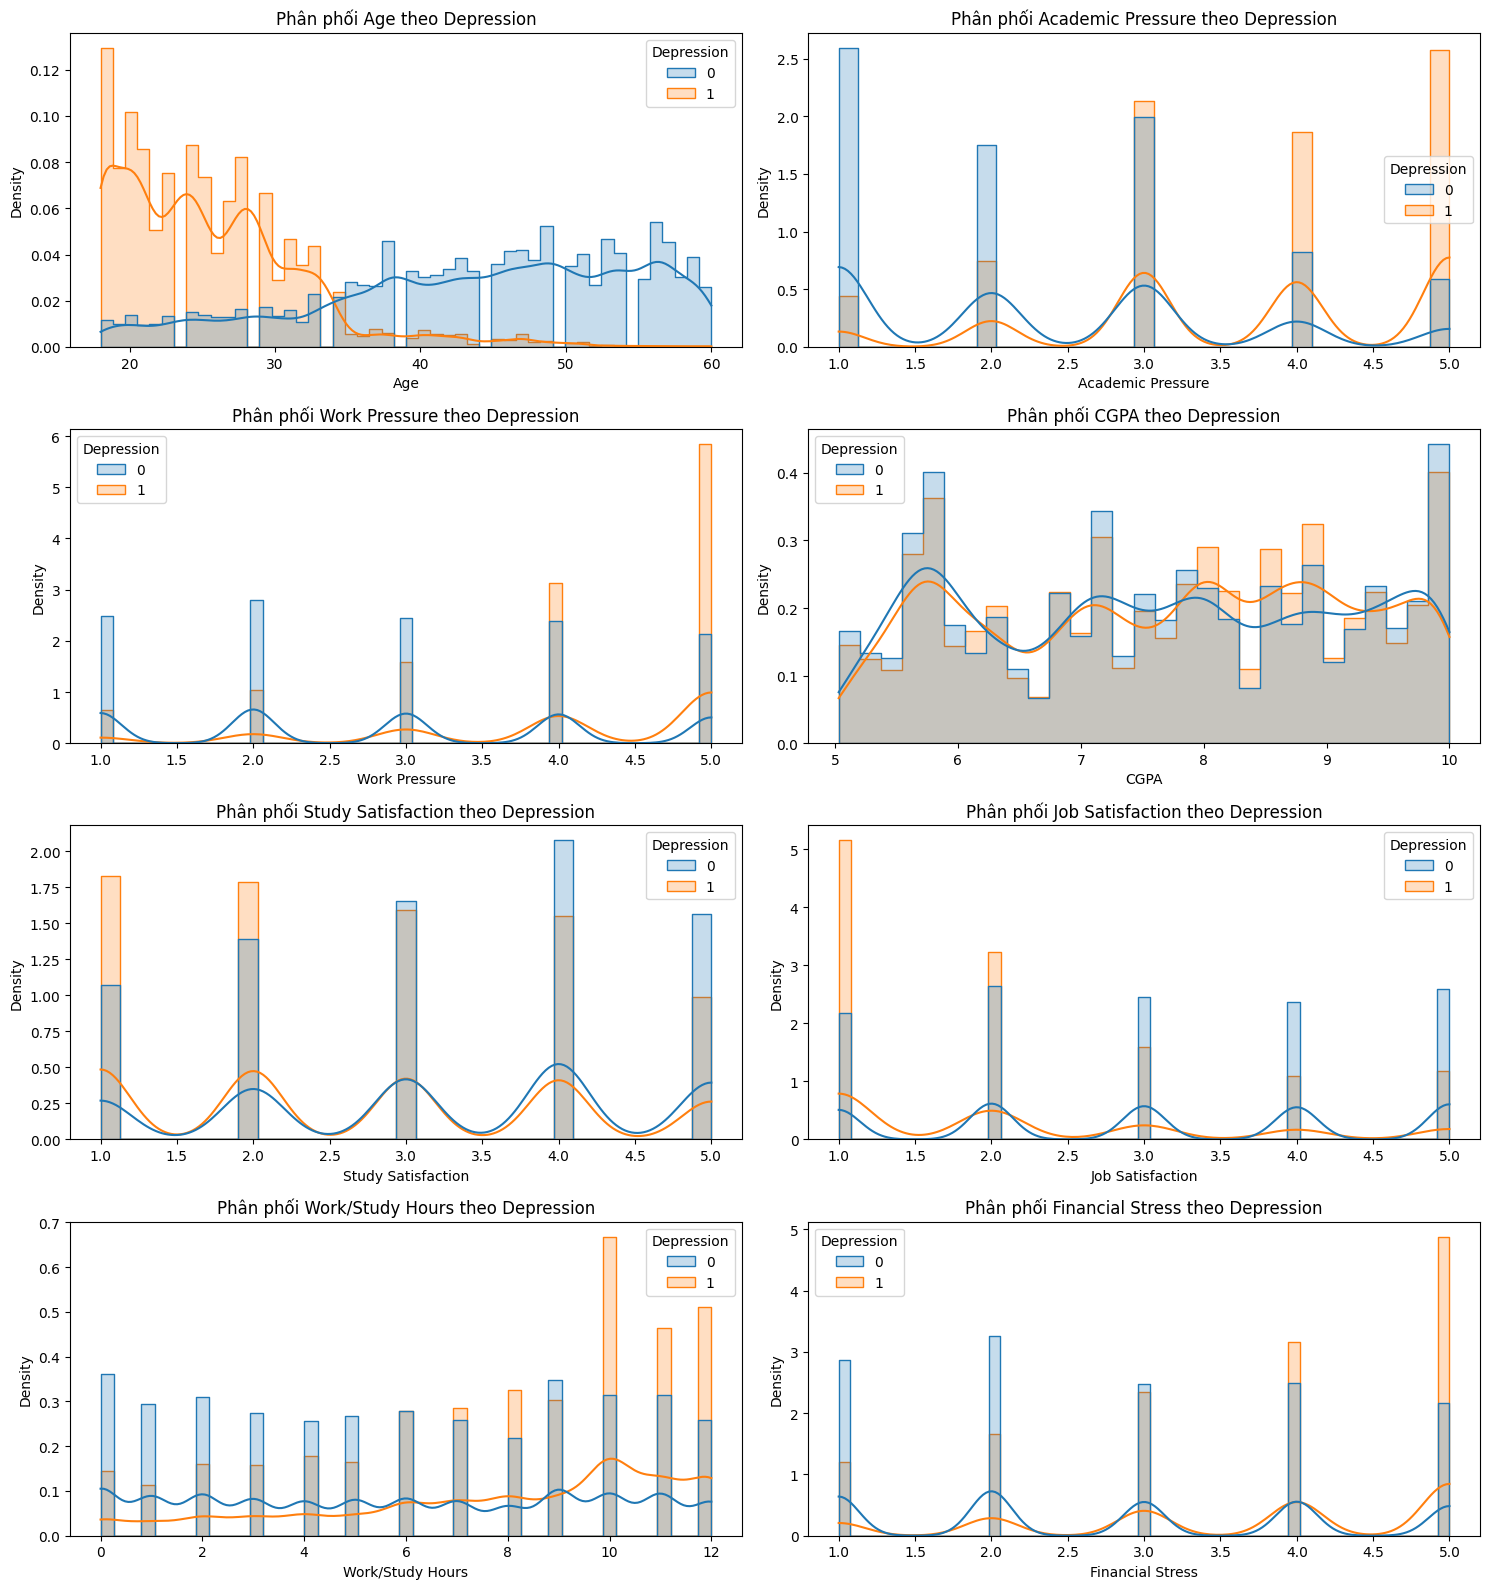

In [12]:
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
feature_numeric_cols = [c for c in numeric_cols if c not in [id_col, target_col]]

summary = train[feature_numeric_cols].describe().T
display(summary)


n_cols = 2
n_rows = int(np.ceil(len(feature_numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, feature_numeric_cols):
    sns.histplot(data=train, x=col, hue=target_col, kde=True, element='step', stat='density', common_norm=False, ax=ax)
    ax.set_title(f'Phân phối {col} theo Depression')

for ax in axes[len(feature_numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
Age,140700.0,27897.0,112782.0,27898.0,27897.0,112790.0,140700.0,140696.0,140700.0
Academic Pressure,27897.0,27897.0,0.0,27894.0,27894.0,2.0,27897.0,27894.0,27897.0
Work Pressure,112782.0,0.0,112782.0,0.0,0.0,112777.0,112782.0,112781.0,112782.0
CGPA,27898.0,27894.0,0.0,27898.0,27895.0,2.0,27898.0,27895.0,27898.0
Study Satisfaction,27897.0,27894.0,0.0,27895.0,27897.0,2.0,27897.0,27894.0,27897.0
Job Satisfaction,112790.0,2.0,112777.0,2.0,2.0,112790.0,112790.0,112789.0,112790.0
Work/Study Hours,140700.0,27897.0,112782.0,27898.0,27897.0,112790.0,140700.0,140696.0,140700.0
Financial Stress,140696.0,27894.0,112781.0,27895.0,27894.0,112789.0,140696.0,140696.0,140696.0
Depression,140700.0,27897.0,112782.0,27898.0,27897.0,112790.0,140700.0,140696.0,140700.0


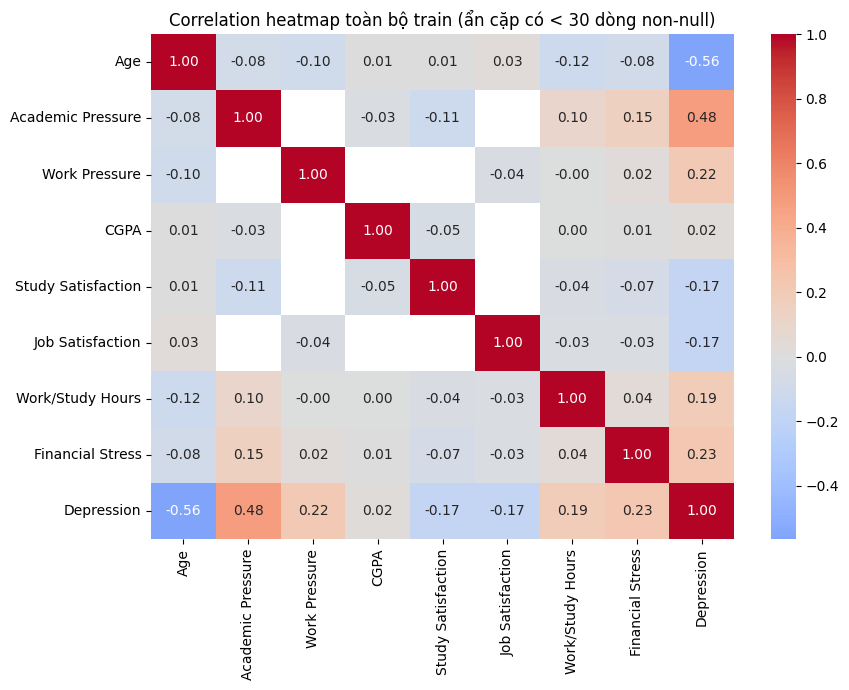

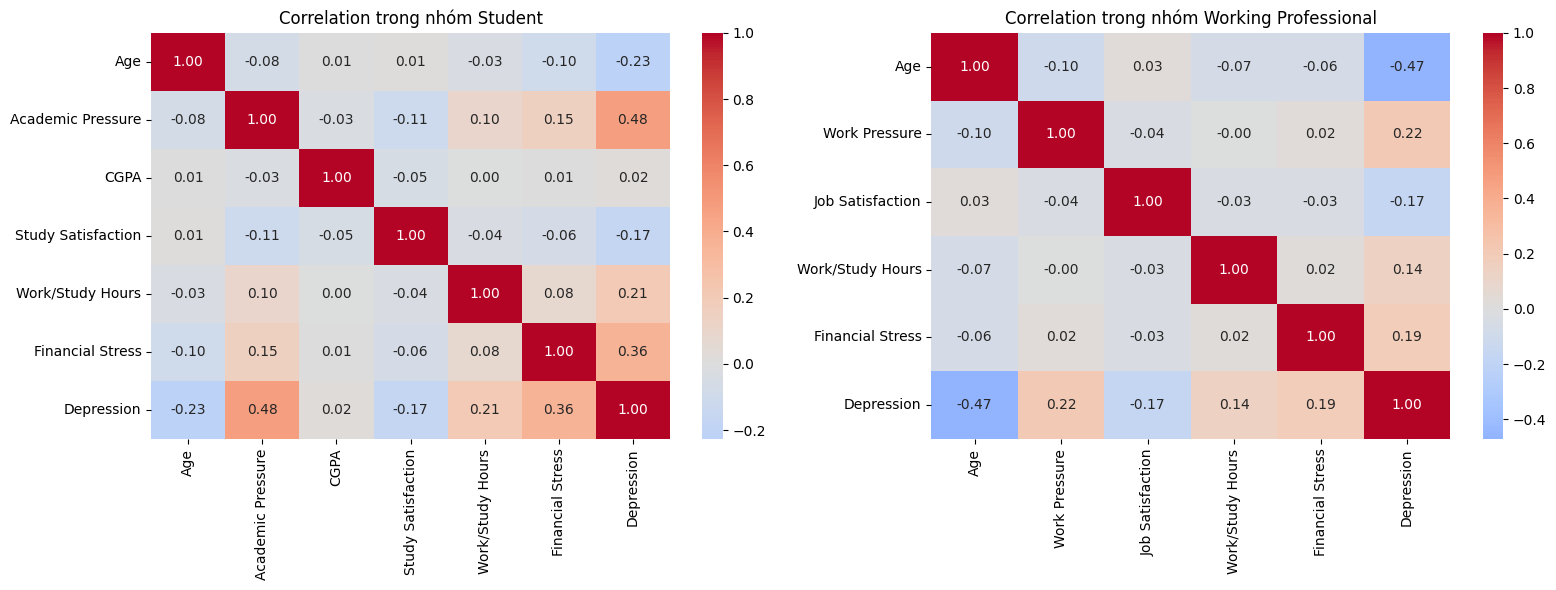

In [16]:
role_col = 'Working Professional or Student'
corr_cols = feature_numeric_cols + [target_col]

# Số dòng cùng non-null cho từng cặp biến. Correlation đáng tin cần đủ mẫu.
pairwise_n = pd.DataFrame(index=corr_cols, columns=corr_cols, dtype=int)
for col_a in corr_cols:
    for col_b in corr_cols:
        pairwise_n.loc[col_a, col_b] = train[[col_a, col_b]].dropna().shape[0]

display(pairwise_n)

min_periods = 30
corr = train[corr_cols].corr(numeric_only=True, min_periods=min_periods)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title(f'Correlation heatmap toàn bộ train (ẩn cặp có < {min_periods} dòng non-null)')
plt.tight_layout()
plt.show()

student_cols = [
    'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
    'Work/Study Hours', 'Financial Stress', target_col
]
professional_cols = [
    'Age', 'Work Pressure', 'Job Satisfaction',
    'Work/Study Hours', 'Financial Stress', target_col
]

student_data = train[train[role_col] == 'Student']
professional_data = train[train[role_col] == 'Working Professional']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    student_data[student_cols].corr(numeric_only=True, min_periods=min_periods),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0]
)
axes[0].set_title('Correlation trong nhóm Student')

sns.heatmap(
    professional_data[professional_cols].corr(numeric_only=True, min_periods=min_periods),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1]
)
axes[1].set_title('Correlation trong nhóm Working Professional')

plt.tight_layout()
plt.show()


In [17]:
categorical_cols = train.select_dtypes(include='object').columns.tolist()
cat_summary = pd.DataFrame({
    'n_unique_train': train[categorical_cols].nunique(dropna=True),
    'missing_pct_train': train[categorical_cols].isna().mean() * 100,
    'n_unique_test': test[categorical_cols].nunique(dropna=True),
    'missing_pct_test': test[categorical_cols].isna().mean() * 100,
}).sort_values('n_unique_train', ascending=False)

display(cat_summary)


,n_unique_train,missing_pct_train,n_unique_test,missing_pct_test
Name,422,0.000000,374,0.000000
Degree,115,0.001421,87,0.002132
City,98,0.000000,68,0.000000
Profession,64,26.034115,64,26.260128
Sleep Duration,36,0.000000,31,0.000000
Dietary Habits,23,0.002843,22,0.005330
Gender,2,0.000000,2,0.000000
Working Professional or Student,2,0.000000,2,0.000000
Have you ever had suicidal thoughts ?,2,0.000000,2,0.000000
Family History of Mental Illness,2,0.000000,2,0.000000


In [20]:
def target_rate_by_category(df, col, target=target_col, min_count=100):
    out = df.groupby(col, dropna=False).agg(
        count=(target, 'size'),
        depression_rate=(target, 'mean')
    ).reset_index()
    out = out[out['count'] >= min_count].sort_values('depression_rate', ascending=False)
    return out

key_cats = [
    'Gender',
    'Working Professional or Student',
    'Sleep Duration',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

for col in key_cats:
    print(f'\nDepression rate by {col}')
    display(target_rate_by_category(train, col, min_count=100).head(20))



Depression rate by Gender


,Gender,count,depression_rate
1,Male,77464,0.184550
0,Female,63236,0.178237



Depression rate by Working Professional or Student


,Working Professional or Student,count,depression_rate
0,Student,27901,0.585499
1,Working Professional,112799,0.081836



Depression rate by Sleep Duration


...

,Dietary Habits,count,depression_rate
20,Unhealthy,46227,0.260540
15,Moderate,49705,0.165637
7,Healthy,44741,0.118035



Depression rate by Have you ever had suicidal thoughts ?


,Have you ever had suicidal thoughts ?,count,depression_rate
1,Yes,69562,0.317832
0,No,71138,0.048610



Depression rate by Family History of Mental Illness


,Family History of Mental Illness,count,depression_rate
1,Yes,69942,0.188113
0,No,70758,0.175387


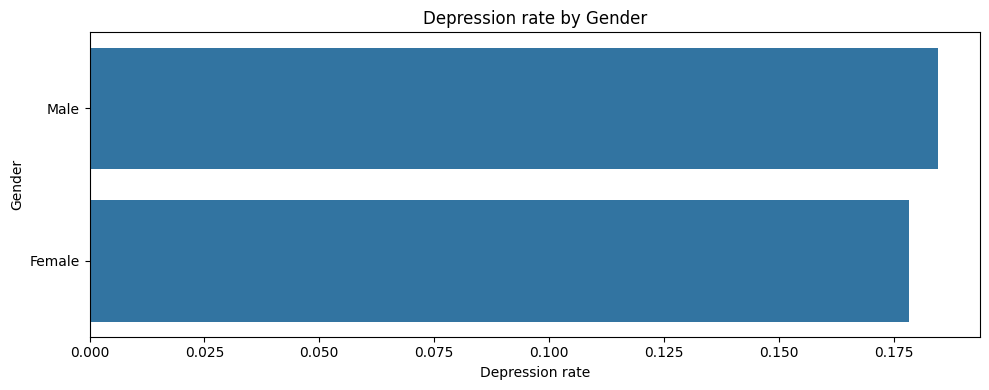

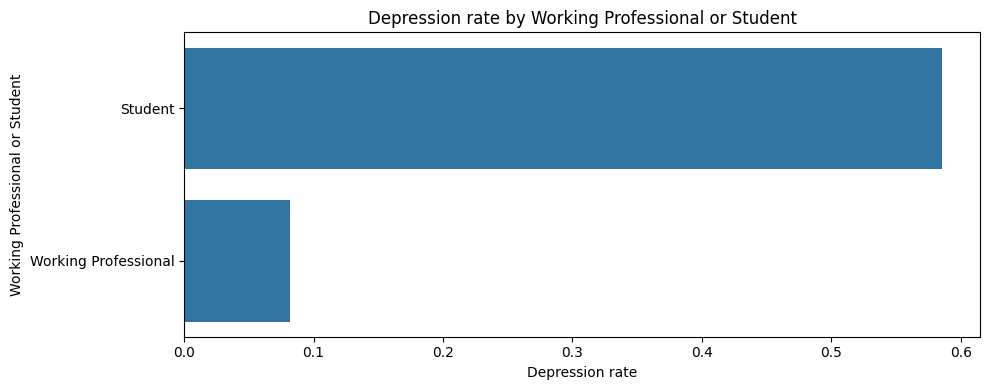

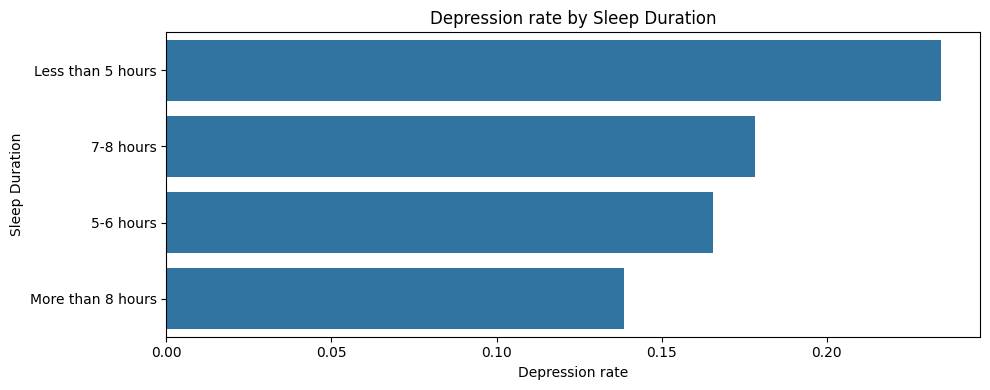

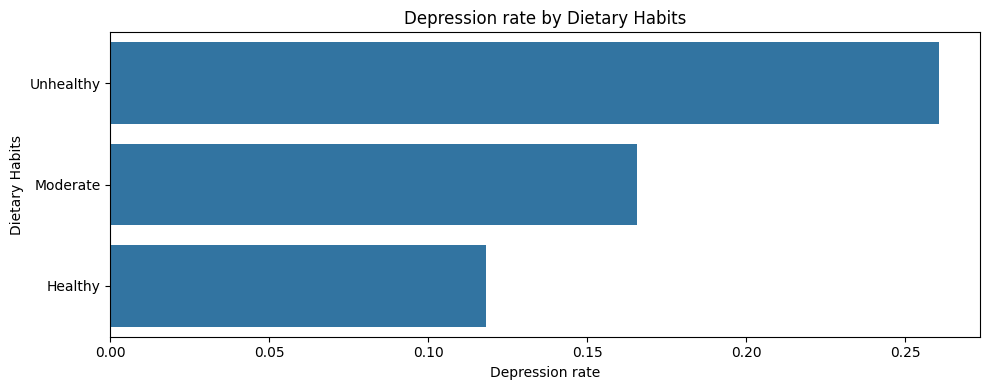

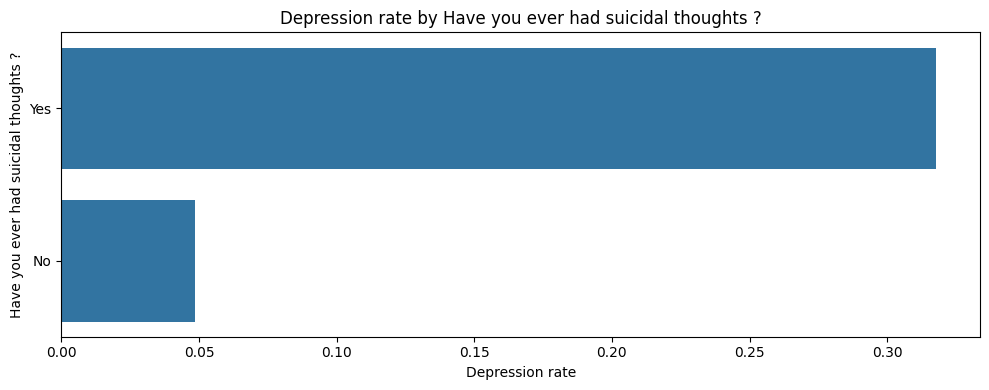

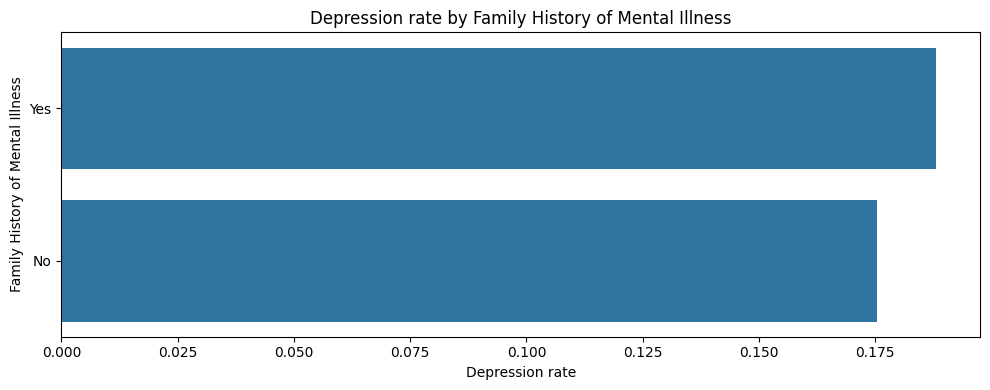

In [21]:
plot_cats = [
    'Gender',
    'Working Professional or Student',
    'Sleep Duration',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

for col in plot_cats:
    rate = target_rate_by_category(train, col, min_count=100).head(20)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(rate))))
    sns.barplot(data=rate, y=col, x='depression_rate', ax=ax)
    ax.set_title(f'Depression rate by {col}')
    ax.set_xlabel('Depression rate')
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

In [22]:
compare_cols = [c for c in train.columns if c != target_col and c in test.columns]
compare = []
for col in compare_cols:
    train_unique = set(train[col].dropna().unique())
    test_unique = set(test[col].dropna().unique())
    compare.append({
        'column': col,
        'train_unique': len(train_unique),
        'test_unique': len(test_unique),
        'only_in_test': len(test_unique - train_unique),
        'only_in_train': len(train_unique - test_unique),
        'train_missing_pct': train[col].isna().mean() * 100,
        'test_missing_pct': test[col].isna().mean() * 100,
    })

compare_df = pd.DataFrame(compare).sort_values(['only_in_test', 'test_unique'], ascending=False)
display(compare_df)

,column,train_unique,test_unique,only_in_test,only_in_train,train_missing_pct,test_missing_pct
0,id,140700,93800,93800,140700,0.000000,0.000000
1,Name,422,374,132,180,0.000000,0.000000
14,Degree,115,87,41,69,0.001421,0.002132
4,City,98,68,26,56,0.000000,0.000000
6,Profession,64,64,17,17,26.034115,26.260128
13,Dietary Habits,23,22,13,14,0.002843,0.005330
12,Sleep Duration,36,31,10,15,0.000000,0.000000
9,CGPA,331,326,7,12,80.171997,79.993603
3,Age,43,44,1,0,0.000000,0.000000
16,Work/Study Hours,13,13,0,0,0.000000,0.000000


In [23]:
for col in categorical_cols:
    only_test = sorted(set(test[col].dropna().unique()) - set(train[col].dropna().unique()))
    if only_test:
        print(f'{col}: {len(only_test)} values only in test')
        print(only_test[:30])

Name: 132 values only in test
['AHM', 'Aalalav', 'Aamir', 'Aandini', 'Aandla', 'Aar', 'Aarhar', 'Aarik', 'Aarjun', 'Aarod', 'Aarohan', 'Aaroor', 'Aarsha', 'Abakression', 'Abha', 'Abharth', 'Abra', 'Abrit', 'Adib', 'Adik', 'Aeshita', 'Ajai', 'Anaghav', 'Ananchal', 'Anarav', 'Aneshv', 'Anishwarya', 'Anita', 'Anmay', 'Anwar']
City: 26 values only in test
['Abhinav', 'Aditi', 'Avni', 'Chemist', 'Ghopal', 'Golkata', 'Hrithik', 'Ira', 'Is Kanpur', 'Lawyer', 'Leela', 'Less than 5 hours', 'Malyan', 'Mhopal', 'More Delhi', 'No.12', 'Pratham', 'Rolkata', 'San Vasai-Virar', 'Sara', 'Saurav', 'Siddhesh', 'Thani', 'Unaly', 'Vaikot', 'Vikram']
Profession: 17 values only in test
['24th', '3M', 'B.Pharm', 'City Consultant', 'M.Pharm', 'M.Tech', 'MCA', 'MD', 'ME', 'Manvi', 'Name', 'No', 'Samar', 'Simran', 'Surat', 'Surgeon', 'Unhealthy']
Sleep Duration: 10 values only in test
['0', '20-21 hours', '50-75 hours', '6 hours', '60-65 hours', '8-89 hours', '9-10 hours', 'Have_you_ever_had_suicidal_thoughts',